In [1]:
!pip install darts matplotlib pandas statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.8/344.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

from darts import TimeSeries
from darts.datasets import AirPassengersDataset
from darts.utils.statistics import check_seasonality, plot_acf, plot_pacf
from darts.models import ARIMA, AutoARIMA
from darts.metrics import mape

# Set plot defaults
plt.rcParams["figure.figsize"] = (12, 6)

In [18]:
co2_data = sm.datasets.co2.load_pandas()
df = co2_data.data  # This is a pandas DataFrame
df['co2'] = df['co2'].ffill()
series_pd = df['co2']
series = TimeSeries.from_series(series_pd, freq='M')

<Axes: xlabel='time'>

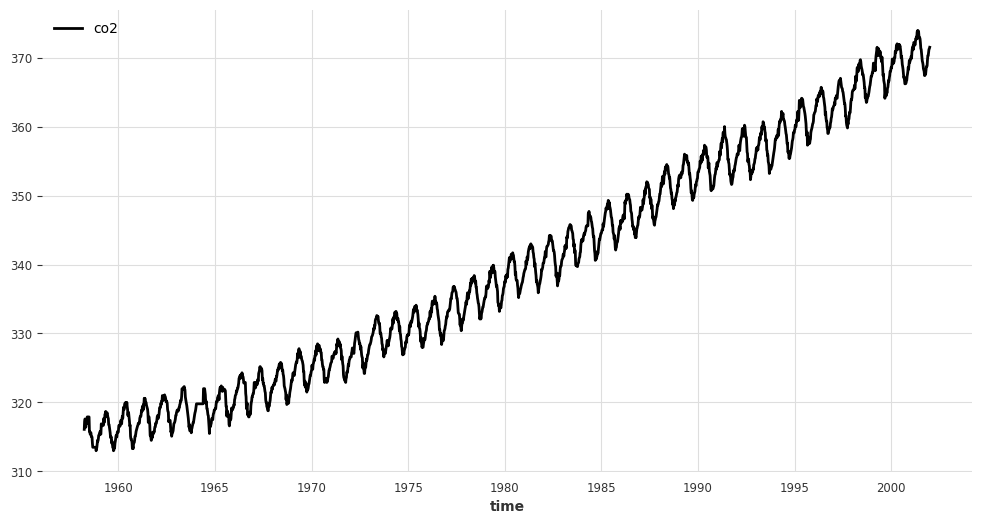

In [19]:
series.plot()

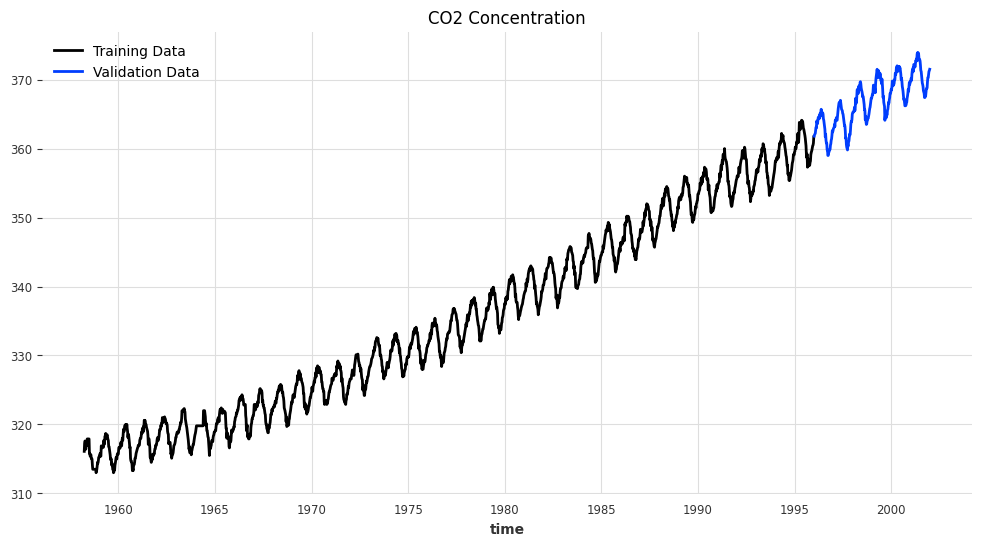

In [20]:
train, val = series.split_before(pd.Timestamp("19960101"))

# Plot the data to get a visual sense
train.plot(label="Training Data")
val.plot(label="Validation Data")
plt.title("CO2 Concentration")
plt.legend();

In [21]:
def adf_test(series):
    """
    Performs the Augmented Dickey-Fuller test for stationarity.
    """
    print("--- Augmented Dickey-Fuller Test ---")
    # The .values.squeeze() is to convert Darts TimeSeries to a NumPy array
    result = adfuller(series.values().squeeze())
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] <= 0.05:
        print("Conclusion: Reject the null hypothesis. The series is likely stationary.")
    else:
        print("Conclusion: Fail to reject the null hypothesis. The series is likely non-stationary.")

In [22]:
adf_test(train)

--- Augmented Dickey-Fuller Test ---
ADF Statistic: -0.15577041035939038
p-value: 0.9435924009774143
Conclusion: Fail to reject the null hypothesis. The series is likely non-stationary.


In [23]:
train = train.diff()

In [24]:
adf_test(train)

--- Augmented Dickey-Fuller Test ---
ADF Statistic: -14.011454645910401
p-value: 3.7073514723368934e-26
Conclusion: Reject the null hypothesis. The series is likely stationary.


In [25]:
train, val = series.split_before(pd.Timestamp("19960101"))

Text(0.5, 1.0, 'PACF of Differenced Series')

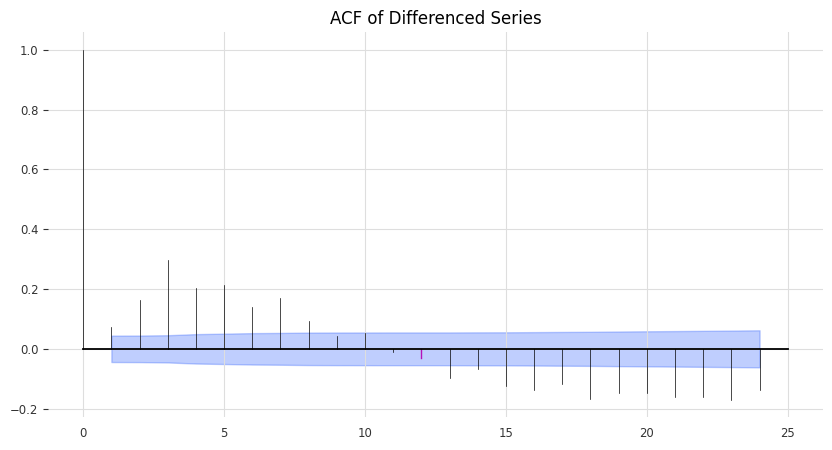

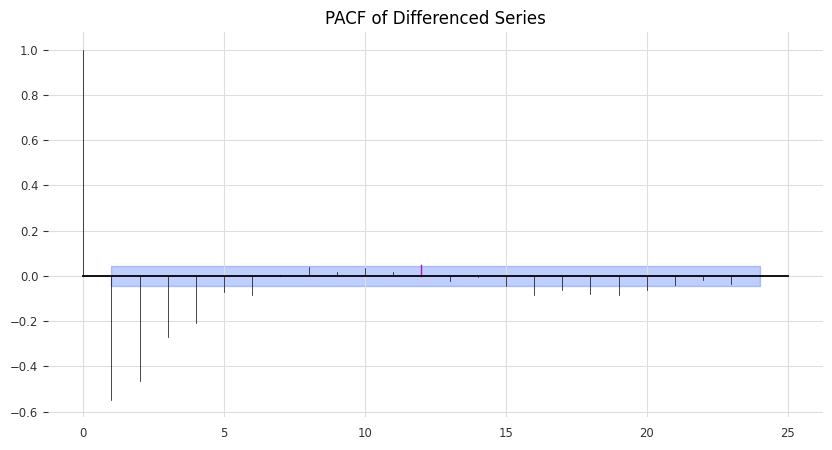

In [28]:
plot_acf(train.diff(), m=12, alpha=0.05)
plt.title("ACF of Differenced Series")

plot_pacf(train.diff().diff(), m=12, alpha=0.05)
plt.title("PACF of Differenced Series")

In [45]:
manual_model = ARIMA()
manual_model.fit(train)
manual_pred = manual_model.predict(n=len(val))
manual_mape = mape(val, manual_pred)
print(manual_mape)

1.4346466147947883


In [50]:
manual_model = ARIMA(d=1, p=4, q=3)
manual_model.fit(train)
manual_pred = manual_model.predict(n=len(val))
manual_mape = mape(val, manual_pred)
print(manual_mape)

1.3762075412789556


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
